Experiment 8: Deep Learning Frameworks

Aim: To study and implement deep learning models using TensorFlow and Keras frameworks

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


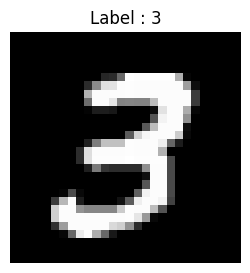

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7199 - loss: 0.9347 - val_accuracy: 0.8623 - val_loss: 0.4515
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8992 - loss: 0.3509 - val_accuracy: 0.8947 - val_loss: 0.3358
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9224 - loss: 0.2667 - val_accuracy: 0.9113 - val_loss: 0.2872
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9393 - loss: 0.2041 - val_accuracy: 0.9223 - val_loss: 0.2587
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9472 - loss: 0.1746 - val_accuracy: 0.9300 - val_loss: 0.2244

Test Loss     : 0.1758
Test Accuracy : 0.9451


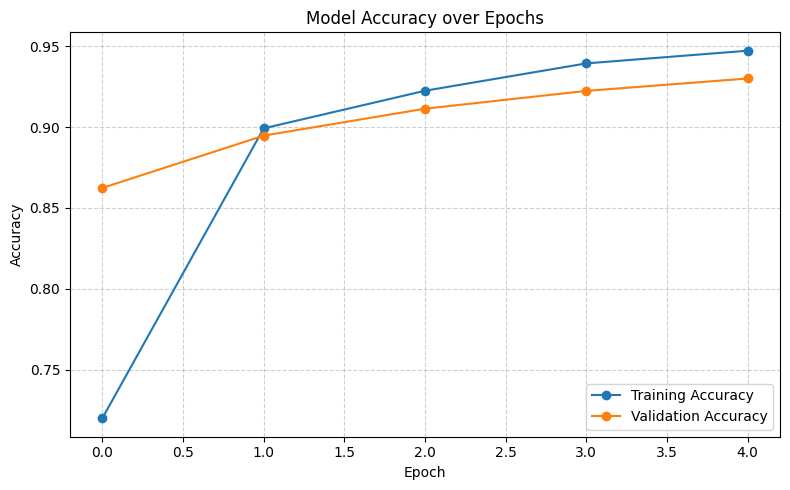

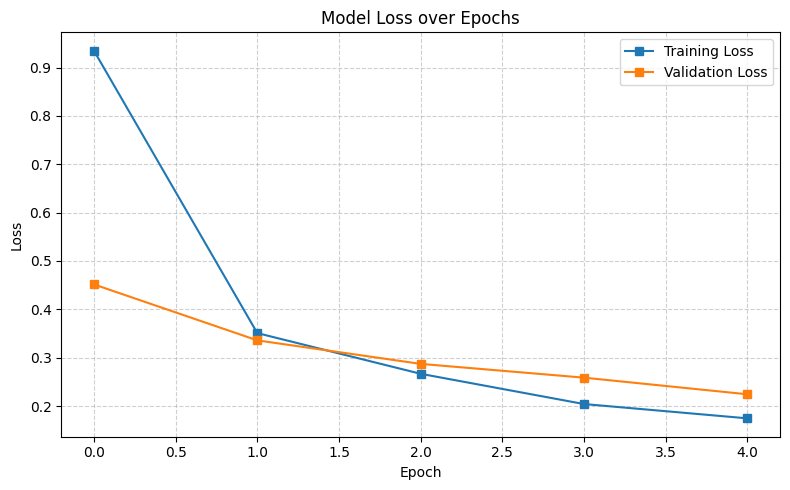


Predicted Label : 3


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout       # Condensed imports
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load MNIST Dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Display Sample Image with label 3
sample_index = np.where(y_train == 3)[0][0]             # Find first image with label 3

plt.figure(figsize=(3, 3))
plt.imshow(X_train[sample_index], cmap='gray')
plt.title(f"Label : {y_train[sample_index]}")
plt.axis('off')
plt.show()

# Normalize Data
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Reshape Dataset
X_train = X_train.reshape(-1, 784)                      # Dynamic reshape
X_test  = X_test.reshape(-1, 784)

# One Hot Encoding
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test,  10)

# Use subset for faster training
X_train_fast = X_train[:15000]                          # 15k instead of 60k
y_train_fast = y_train[:15000]

# Build Neural Network Model
model = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),  # Reduced from 512
    Dropout(0.2),
    Dense(128, activation='relu'),                      # Reduced from 256
    Dropout(0.2),
    Dense(10,  activation='softmax')
])

# Model Summary
model.summary()

# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X_train_fast,                                       # Subset of training data
    y_train_fast,
    epochs=5,                                           # Reduced from 10
    batch_size=256,                                     # Increased from 128
    validation_split=0.2,
    verbose=1
)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

# Plot Accuracy Graph
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'],     label='Training Accuracy',   marker='o', linewidth=1.5)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o', linewidth=1.5)

plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot Loss Graph
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'],     label='Training Loss',   marker='s', linewidth=1.5)
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s', linewidth=1.5)

plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Predict Sample with label 3
sample_index = np.where(y_test.argmax(axis=1) == 3)[0][0]   # Find test image with label 3
prediction = model.predict(X_test[sample_index:sample_index+1], verbose=0)

predicted_label = np.argmax(prediction)
print(f"\nPredicted Label : {predicted_label}")

Conclusion: Successfully implemented deep learning models using TensorFlow and Keras frameworks on the MNIST handwritten digit dataset.